# Notebook 1 — Data Check & Audit

**Project:** Speech Emotion Recognition (SER) on the RAVDESS dataset (audio-only).

**This notebook does four things:**

1. Walk the `data/` directory and parse every `.wav` filename into a structured row.
2. Verify dataset integrity — counts, modality, missing actors, file corruption, sample rates.
3. Characterize the class distribution (emotion, vocal channel, intensity, actor, gender, duration).
4. Save `metadata.csv` as the source of truth for every later notebook.

**Source:** Livingstone & Russo (2018), [RAVDESS on Zenodo](https://zenodo.org/records/1188976). Audio-only subset = 1,440 speech + 1,012 song = **2,452 files**.

## 1. Imports & config

In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import soundfile as sf
from tqdm import tqdm

SEED = 28

DATA = Path("../data")
OUTPUT = Path("../features")

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

## 2. Filename schema

Every RAVDESS file is named `MM-VV-EE-II-SS-RR-AA.wav`. Example: `03-01-05-01-02-01-12.wav`.

| Position | Meaning | Values |
|----------|---------|--------|
| 1 | Modality | 01 = full-AV, 02 = video-only, **03 = audio-only** |
| 2 | Vocal channel | **01 = speech**, **02 = song** |
| 3 | **Emotion** | 01 = neutral, 02 = calm, 03 = happy, 04 = sad, 05 = angry, 06 = fearful, 07 = disgust, 08 = surprised |
| 4 | Intensity | 01 = normal, 02 = strong (no strong for neutral) |
| 5 | Statement | 01 = "Kids are talking by the door", 02 = "Dogs are sitting by the door" |
| 6 | Repetition | 01 = 1st, 02 = 2nd |
| 7 | Actor | 01–24 (odd = male, even = female) |

Position 3 is the supervised target. Everything else is metadata for slicing, stratification, and CV grouping.

In [2]:
EMOTIONS = {1:"neutral", 2:"calm", 3:"happy", 4:"sad", 5:"angry", 6:"fearful", 7:"disgust", 8:"surprised"}
INTENSITY = {1:"normal", 2:"strong"}
STATEMENT_TYPE = {1:"kidsdoor", 2:"dogsdoor"}
AUDIOTYPE = {1:"speech", 2:"song"}

EMOTION_ORDER = ["neutral", "calm", "happy", "sad", "angry", "fearful", "disgust", "surprised"]

def parseFileName(path):
    """Parse a RAVDESS filename into a structured dict. Raises ValueError on malformed names."""
    stem = Path(path).stem
    parts = stem.split("-")
    if len(parts) != 7:
        raise ValueError(f"Unexpected filename: {stem}")
    try:
        modality, vocal, emotion, intensity, statement, rep, actor = (int(p) for p in parts)
    except ValueError as err:
        raise ValueError(f"Non-integer part in filename: {stem}") from err

    return {
        "filepath": str(path),
        "filename": stem,
        "modality": modality,
        "vocalchannel": AUDIOTYPE[vocal],
        "emotion_id": emotion,
        "emotion": EMOTIONS[emotion],
        "intensity": INTENSITY[intensity],
        "statement": STATEMENT_TYPE[statement],
        "repetition": rep,
        "actor": actor,
        "gender": "male" if actor % 2 == 1 else "female",
    }

parseFileName("03-01-05-02-01-01-12.wav")

{'filepath': '03-01-05-02-01-01-12.wav',
 'filename': '03-01-05-02-01-01-12',
 'modality': 3,
 'vocalchannel': 'speech',
 'emotion_id': 5,
 'emotion': 'angry',
 'intensity': 'strong',
 'statement': 'kidsdoor',
 'repetition': 1,
 'actor': 12,
 'gender': 'female'}

## 3. Walk the data directory and build the metadata table

RAVDESS unzips into `Actor_01/ ... Actor_24/`, with both speech and song files mixed inside each actor folder. We use a single recursive glob and let `parseFileName` separate speech vs song into a column — no filesystem reorganization needed.

In [3]:
wavFiles = sorted(DATA.rglob("*.wav"))
print(f"total wavs: {len(wavFiles)}")

records = [parseFileName(p) for p in wavFiles]
meta = pd.DataFrame(records)
meta.head()

total wavs: 2452


,filepath,filename,modality,vocalchannel,emotion_id,emotion,intensity,statement,repetition,actor,gender
0,../data/Actor_01/03-01-01-01-01-01-01.wav,03-01-01-01-01-01-01,3,speech,1,neutral,normal,kidsdoor,1,1,male
1,../data/Actor_01/03-01-01-01-01-02-01.wav,03-01-01-01-01-02-01,3,speech,1,neutral,normal,kidsdoor,2,1,male
2,../data/Actor_01/03-01-01-01-02-01-01.wav,03-01-01-01-02-01-01,3,speech,1,neutral,normal,dogsdoor,1,1,male
3,../data/Actor_01/03-01-01-01-02-02-01.wav,03-01-01-01-02-02-01,3,speech,1,neutral,normal,dogsdoor,2,1,male
4,../data/Actor_01/03-01-02-01-01-01-01.wav,03-01-02-01-01-01-01,3,speech,2,calm,normal,kidsdoor,1,1,male


## 4. Structural sanity checks

Before plotting anything, verify the dataset matches the published spec:

- 1,440 speech + 1,012 song = 2,452 total
- Every file has modality `03`
- Speech covers all 24 actors; song covers 23 (actor 18 has no song recordings)
- Speech covers all 8 emotions; song covers only 6 (no `disgust`, no `surprised`)

If any of these fail, stop and re-check the unzip before continuing.

In [4]:
speech = meta[meta.vocalchannel == "speech"]
song   = meta[meta.vocalchannel == "song"]

assert len(speech) == 1440, f"expected 1440 speech files, got {len(speech)}"
assert len(song) == 1012,   f"expected 1012 song files, got {len(song)}"
assert (meta.modality == 3).all(), "all files should be modality 03 (audio-only)"

assert speech.actor.nunique() == 24, "speech should cover all 24 actors"
assert song.actor.nunique() == 23,   "song should cover 23 actors"
assert 18 not in song.actor.values,  "actor 18 should be missing from song subset"

songEmotions = set(song.emotion.unique())
assert songEmotions == {"neutral", "calm", "happy", "sad", "angry", "fearful"}, \
    f"unexpected song emotion set: {songEmotions}"

print("data is structured correctly")
print(f"  speech: {len(speech)} files, {speech.actor.nunique()} actors, {speech.emotion.nunique()} emotions")
print(f"  song:   {len(song)} files, {song.actor.nunique()} actors, {song.emotion.nunique()} emotions")

data is structured correctly
  speech: 1440 files, 24 actors, 8 emotions
  song:   1012 files, 23 actors, 6 emotions


## 5. Audio file integrity probe

Read each file's WAV header (not the full waveform) to catch corruption, off-spec sample rates, unexpected bit depths, or stereo files masquerading as mono. `sf.info` reads the header only — fast (~1 second total) and avoids loading 400 MB of audio into RAM.

Per the RAVDESS spec, every file should be **48 kHz, 16-bit PCM, mono**.

In [5]:
def probe(path):
    """Read WAV header only. Returns dict with sample rate, duration, channels, subtype."""
    try:
        info = sf.info(path)
        return {"ok": True, "sr": info.samplerate, "duration": info.duration,
                "channels": info.channels, "subtype": info.subtype, "error": None}
    except Exception as err:
        return {"ok": False, "sr": None, "duration": None,
                "channels": None, "subtype": None, "error": str(err)}

probe_df = pd.DataFrame([probe(p) for p in tqdm(meta.filepath, desc="probing")])

# Idempotent — assigning by column name overwrites instead of duplicating on re-run.
for col in ["ok", "sr", "duration", "channels", "subtype", "error"]:
    meta[col] = probe_df[col].values

n_corrupt = (~meta.ok).sum()
print(f"Corrupted / unreadable files: {n_corrupt}")
print(f"Sample rates:   {meta.sr.value_counts().to_dict()}")
print(f"Channel counts: {meta.channels.value_counts().to_dict()}")
print(f"Subtypes:       {meta.subtype.value_counts().to_dict()}")
print(f"Duration:       min={meta.duration.min():.2f}s  max={meta.duration.max():.2f}s  "
      f"mean={meta.duration.mean():.2f}s")

probing: 100%|█████████████████████████████| 2452/2452 [00:01<00:00, 1964.80it/s]

Corrupted / unreadable files: 0
Sample rates:   {48000: 2452}
Channel counts: {1: 2446, 2: 6}
Subtypes:       {'PCM_16': 2452}
Duration:       min=2.94s  max=6.37s  mean=4.09s


## 6. Class distribution — emotion

The supervised target is `emotion`. Need to know how balanced the classes are before any modeling decisions.

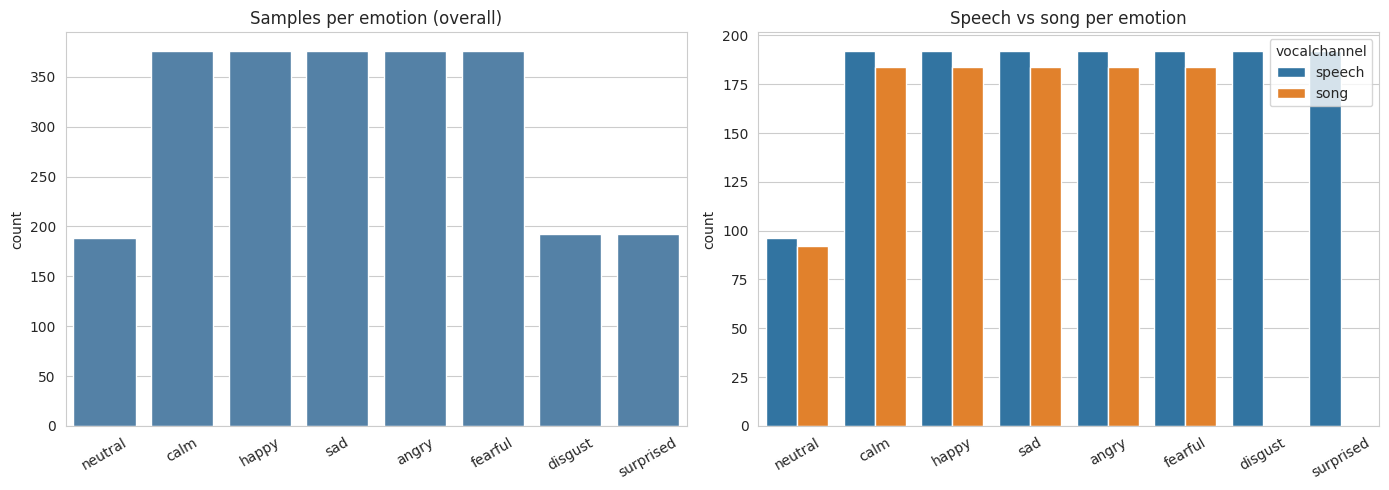

vocalchannel  song  speech
emotion                   
neutral         92      96
calm           184     192
happy          184     192
sad            184     192
angry          184     192
fearful        184     192
disgust          0     192
surprised        0     192


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=meta, x="emotion", order=EMOTION_ORDER, ax=axes[0], color="steelblue")
axes[0].set_title("Samples per emotion (overall)")
axes[0].set_xlabel(""); axes[0].set_ylabel("count")
axes[0].tick_params(axis="x", rotation=30)

sns.countplot(data=meta, x="emotion", hue="vocalchannel", order=EMOTION_ORDER, ax=axes[1])
axes[1].set_title("Speech vs song per emotion")
axes[1].set_xlabel(""); axes[1].set_ylabel("count")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout(); plt.show()

print(meta.groupby(["emotion", "vocalchannel"]).size().unstack(fill_value=0).loc[EMOTION_ORDER])

**Findings.** Two things shape the rest of the project. First, **neutral has roughly half the samples** of every other emotion — RAVDESS has no `strong` intensity variant for neutral (there is no semantically coherent "very neutral" performance), so neutral comes with one intensity level instead of two. Raw accuracy will reward models that simply avoid predicting neutral; we'll use stratified splits and macro-F1 as the headline metric. Second, **song covers a smaller emotion set than speech** — no `disgust`, no `surprised`. Speech-only is the natural starting point for modeling (8 classes, balanced per actor); song folds in later as a separate experiment or robustness check.

## 7. Class distribution — actor, gender, intensity

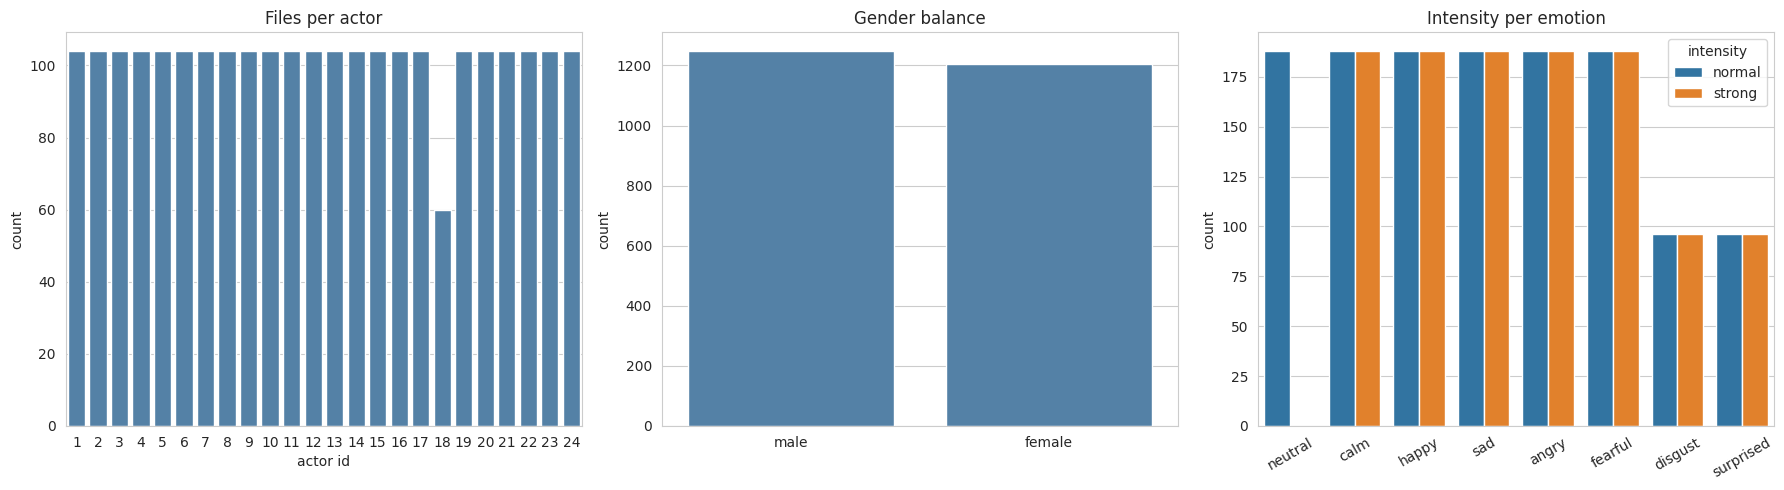

Actor 18 file count: 60  (speech only)
Other actors avg:    104.0


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=meta, x="actor", ax=axes[0], color="steelblue")
axes[0].set_title("Files per actor")
axes[0].set_xlabel("actor id"); axes[0].set_ylabel("count")

sns.countplot(data=meta, x="gender", ax=axes[1], color="steelblue")
axes[1].set_title("Gender balance")
axes[1].set_xlabel(""); axes[1].set_ylabel("count")

sns.countplot(data=meta, x="emotion", hue="intensity", order=EMOTION_ORDER, ax=axes[2])
axes[2].set_title("Intensity per emotion")
axes[2].set_xlabel(""); axes[2].set_ylabel("count")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout(); plt.show()

print(f"Actor 18 file count: {(meta.actor == 18).sum()}  (speech only)")
print(f"Other actors avg:    {meta[meta.actor != 18].groupby('actor').size().mean():.1f}")

**Findings.** Gender is balanced 12/12 — odd actors are male, even are female — so gender bias from class imbalance isn't a concern. Actor 18 contributes ~60 files (speech only) versus ~104 for everyone else; small enough not to skew aggregates but it shapes the cross-validation strategy. Most importantly: **subject-independent CV is the right protocol for SER.** A naive random split lets the same actor's `kidsdoor` utterance appear in both train and test, and the model can pass the test by memorizing voice rather than learning emotion. We'll group on `actor` when setting up cross-validation in week 12. Intensity is binary with neutral as the exception — every non-neutral emotion has roughly equal `normal` and `strong` counts, and the neutral imbalance is fully attributable to the missing `strong` variant.

## 8. Clip duration

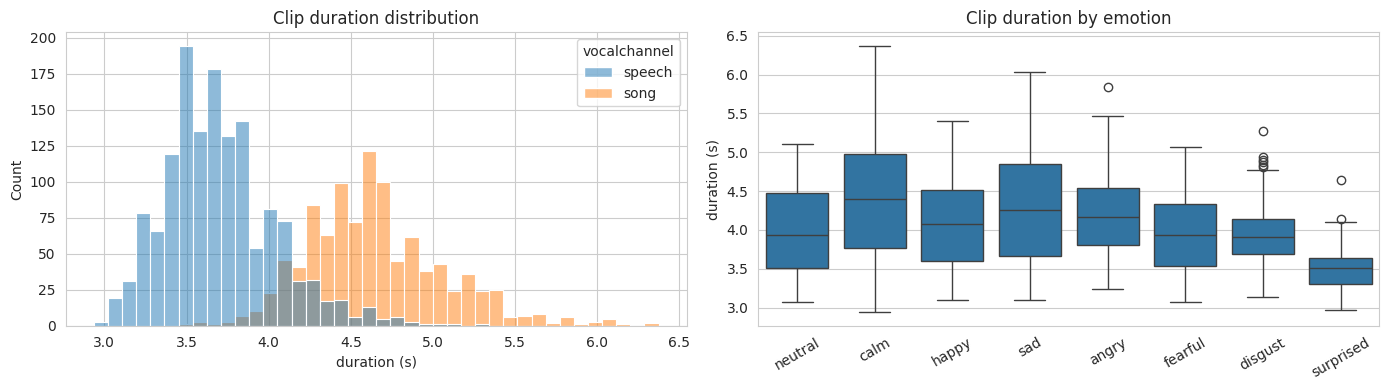

Duration percentiles by vocal channel:
                   min        5%       50%       95%       max      mean
vocalchannel                                                            
song          3.503500  4.070729  4.604604  5.405396  6.373042  4.649210
speech        2.936271  3.203208  3.670333  4.305980  5.271937  3.700665


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(data=meta, x="duration", hue="vocalchannel", bins=40, ax=axes[0])
axes[0].set_title("Clip duration distribution")
axes[0].set_xlabel("duration (s)")

sns.boxplot(data=meta, x="emotion", y="duration", order=EMOTION_ORDER, ax=axes[1])
axes[1].set_title("Clip duration by emotion")
axes[1].set_xlabel(""); axes[1].set_ylabel("duration (s)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout(); plt.show()

print("Duration percentiles by vocal channel:")
print(meta.groupby("vocalchannel")["duration"]
          .describe(percentiles=[0.05, 0.5, 0.95])[["min", "5%", "50%", "95%", "max", "mean"]])

**Findings.** Speech clips cluster around 3–4 seconds; song clips run noticeably longer (the actors sing the same statement, which extends duration). This matters for feature extraction: per-frame features like MFCC, ZCR, and spectral centroid produce variable-length matrices, so each file gets summarized with statistics (mean, std, percentiles) over the time axis to produce a fixed-length vector. Wildly different durations don't break that approach but are worth keeping in mind if a deep model later wants padded sequences.

## 9. Audit summary

- **Counts verified.** 1,440 speech + 1,012 song = 2,452 files, all modality `03`, uniform 48 kHz / 16-bit PCM mono, zero corruption.
- **Class imbalance.** Neutral has ~half the samples (no `strong` variant by design); song subset omits `disgust` and `surprised`. Use stratified sampling and macro-F1, not raw accuracy.
- **Subject structure.** 24 actors (12M / 12F), actor 18 missing from song. Cross-validation must group on actor to avoid voice-identity leakage.
- **Duration.** Speech ≈ 3–4s, song longer; per-file feature vectors will be built from frame-level summary statistics.
- **Modeling decision.** Speech-only is the natural starting point (8 classes, full per-actor coverage); song folds in as a separate experiment in later notebooks.

## 10. Save the metadata table

Every later notebook starts with `meta = pd.read_csv("../features/metadata.csv")`.

In [9]:
OUTPUT.mkdir(exist_ok=True)

csvPath = OUTPUT / "metadata.csv"
meta.to_csv(csvPath, index=False)

print(f"Saved {len(meta)} rows to {csvPath.resolve()}")

Saved 2452 rows to /home/deanomeano/coursework/cse432/projects432/serProject/features/metadata.csv
